# Importing necessary libraries and preparing data

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing the clean dataset
df_cleaned_telco = pd.read_csv("../data/cleaned_telco.csv", sep=",")

# Checking
df_cleaned_telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,0,1,3.0,1,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Monthly,0,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1,1,0,2.0,1,Yes,DSL,No,...,No internet service,Yes,No,No,One year,1,Bank transfer (automatic),23.15,46.30,No
2,CUST00003,Female,0,0,0,42.0,1,Yes,DSL,No,...,No,No,Yes,Yes,Monthly,0,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0,0,1,40.0,1,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Monthly,0,Electronic check,75.04,3001.60,No
4,CUST00005,Male,1,1,1,17.0,1,Yes,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,1,Electronic check,22.38,380.46,Yes


In [3]:
# DataFrame info
df_cleaned_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66433 entries, 0 to 66432
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        66433 non-null  object 
 1   gender            66433 non-null  object 
 2   SeniorCitizen     66433 non-null  int64  
 3   Partner           66433 non-null  int64  
 4   Dependents        66433 non-null  int64  
 5   tenure            66433 non-null  float64
 6   PhoneService      66433 non-null  int64  
 7   MultipleLines     66433 non-null  object 
 8   InternetService   66433 non-null  object 
 9   OnlineSecurity    66433 non-null  object 
 10  OnlineBackup      66433 non-null  object 
 11  DeviceProtection  66433 non-null  object 
 12  TechSupport       66433 non-null  object 
 13  StreamingTV       66433 non-null  object 
 14  StreamingMovies   66433 non-null  object 
 15  Contract          66433 non-null  object 
 16  PaperlessBilling  66433 non-null  int64 

- I can see that int8 columns have been changed to int64
- int64 consumes more space
- Need to bring back all int64 columns to int8

In [4]:
def convert_from_int64_to_int8(df):
    """To convert int64 columns to int8"""
    df_copy = df.copy(deep=True)
    col_int64 = [col for col in df_copy.columns if df_copy[col].dtype == "int64"]
    
    for col in col_int64:
        df_copy[col] = df_copy[col].astype("int8")

    return df_copy


In [5]:
# Appplying the function
df_cleaned_telco = convert_from_int64_to_int8(df_cleaned_telco)

In [6]:
# Checking if conversion worked
df_cleaned_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66433 entries, 0 to 66432
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        66433 non-null  object 
 1   gender            66433 non-null  object 
 2   SeniorCitizen     66433 non-null  int8   
 3   Partner           66433 non-null  int8   
 4   Dependents        66433 non-null  int8   
 5   tenure            66433 non-null  float64
 6   PhoneService      66433 non-null  int8   
 7   MultipleLines     66433 non-null  object 
 8   InternetService   66433 non-null  object 
 9   OnlineSecurity    66433 non-null  object 
 10  OnlineBackup      66433 non-null  object 
 11  DeviceProtection  66433 non-null  object 
 12  TechSupport       66433 non-null  object 
 13  StreamingTV       66433 non-null  object 
 14  StreamingMovies   66433 non-null  object 
 15  Contract          66433 non-null  object 
 16  PaperlessBilling  66433 non-null  int8  

# Feature Engineering

## Tenure groups

- It is interesting to create tenure groups since it is easy for both humans and ML models to draw relevant patterns from this

In [36]:
# Viewing range of values for tenure
df_cleaned_telco["tenure"].describe()

count    66433.000000
mean        22.940767
std         15.337956
min          1.000000
25%         10.000000
50%         20.000000
75%         34.000000
max         72.000000
Name: tenure, dtype: float64

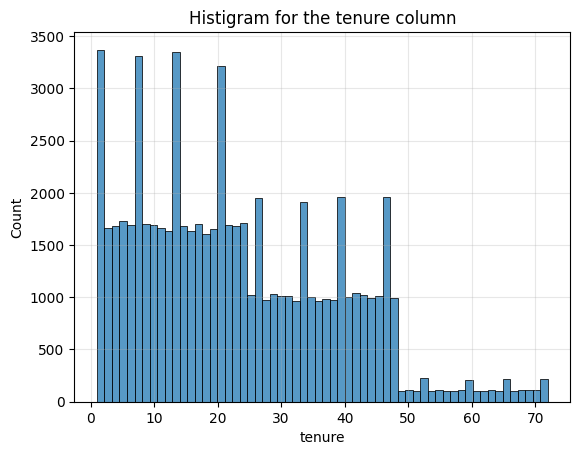

In [37]:
# Histogram for tenure

plt.figure()
sns.histplot(x="tenure", data=df_cleaned_telco)
plt.title("Histigram for the tenure column")
plt.grid(True, alpha=0.3)
plt.show()

### Binning tenure into intervals

In [38]:
# Define bins and labels
bins = [0, 12, 24, 48, 72, 100]
labels =["0-1", "1-2", "2-4", "4-6", "Over 6 years"]

# Actually binning the data
df_cleaned_telco["TenureGroups"] = pd.cut(
    df_cleaned_telco["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [39]:
# Checking
df_cleaned_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66433 entries, 0 to 66432
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        66433 non-null  object  
 1   gender            66433 non-null  object  
 2   SeniorCitizen     66433 non-null  int8    
 3   Partner           66433 non-null  int8    
 4   Dependents        66433 non-null  int8    
 5   tenure            66433 non-null  float64 
 6   PhoneService      66433 non-null  int8    
 7   MultipleLines     66433 non-null  object  
 8   InternetService   66433 non-null  object  
 9   OnlineSecurity    66433 non-null  int64   
 10  OnlineBackup      66433 non-null  int64   
 11  DeviceProtection  66433 non-null  int64   
 12  TechSupport       66433 non-null  int64   
 13  StreamingTV       66433 non-null  int64   
 14  StreamingMovies   66433 non-null  int64   
 15  Contract          66433 non-null  object  
 16  PaperlessBilling  6643

In [40]:
df_cleaned_telco["TenureGroups"].value_counts()

TenureGroups
2-4             23779
0-1             20139
1-2             19934
4-6              2581
Over 6 years        0
Name: count, dtype: int64

## Flagging month to month contracts

- Identifying whether contracts are monthly may help identify patterns
- This is because these clients turn to have little engagements with the company and so may turn to churn more

### Starting by viewing possible values in the column

In [41]:
df_cleaned_telco["Contract"].value_counts()

Contract
Monthly     39863
One year    13302
Two year    13268
Name: count, dtype: int64

### Creating new column based flagging monthly contracts

In [42]:
df_cleaned_telco["IsMonthly"] = (df_cleaned_telco["Contract"] == "Monthly").astype("int8")

In [43]:
# Checking if all went well
df_cleaned_telco[["Contract", "IsMonthly"]].head(10)

,Contract,IsMonthly
0,Monthly,1
1,One year,0
2,Monthly,1
3,Monthly,1
4,Two year,0
5,One year,0
6,One year,0
7,Two year,0
8,Monthly,1
9,One year,0


In [44]:
df_cleaned_telco["IsMonthly"].value_counts()

IsMonthly
1    39863
0    26570
Name: count, dtype: int64

## Flagging single customers

- These are customers that have no sexual partner and children
- Having a partner or a child might influence will influence the over all budget allocation
- Customers with many people on their responsibility might turn to churn more, we are going to verify this later on

### Starting by checking possible values the Partner and Dependents column can take

#### Partner

In [45]:
df_cleaned_telco["Partner"].value_counts()

Partner
0    39714
1    26719
Name: count, dtype: int64

#### Dependents

In [46]:
df_cleaned_telco["Dependents"].value_counts()

Dependents
0    46445
1    19988
Name: count, dtype: int64

### Creating new column based on flagging non single customer

In [47]:
df_cleaned_telco["IsSingle"] = ((df_cleaned_telco["Partner"] == 1) & (df_cleaned_telco["Dependents"] == 1)).astype("int8")

In [48]:
# Checking all worked well
df_cleaned_telco[["Partner", "Dependents","IsSingle"]]

,Partner,Dependents,IsSingle
0,0,1,0
1,1,0,0
2,0,0,0
3,0,1,0
4,1,1,1
...,...,...,...
66428,1,1,1
66429,1,0,0
66430,0,0,0
66431,0,0,0


In [49]:
# Checking distribution of values
df_cleaned_telco["IsSingle"].value_counts()

IsSingle
0    58502
1     7931
Name: count, dtype: int64

## Total added Services

- This is a measure of the number of services each customer added to the most common options : PhoneService, MultipleLines, InternetService
- They help to measure customer engagement with what the company provides
- The concerned columns here are : OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

### Checking possible values for each of the columns

In [50]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

for col in service_cols:
    print(df_cleaned_telco[col].value_counts(), end="\n\n\n")

OnlineSecurity
0    55806
1    10627
Name: count, dtype: int64


OnlineBackup
0    55739
1    10694
Name: count, dtype: int64


DeviceProtection
0    55723
1    10710
Name: count, dtype: int64


TechSupport
0    55781
1    10652
Name: count, dtype: int64


StreamingTV
0    55624
1    10809
Name: count, dtype: int64


StreamingMovies
0    55719
1    10714
Name: count, dtype: int64




### Now let's overwrite the columns value replacing yes by 1 and any else with 0

In [51]:
for col in service_cols:
    df_cleaned_telco[col] = df_cleaned_telco[col].transform(lambda x: 1 if x == "Yes" else 0)

In [52]:
for col in service_cols:
    print(df_cleaned_telco[col].value_counts(), end="\n\n\n")

OnlineSecurity
0    66433
Name: count, dtype: int64


OnlineBackup
0    66433
Name: count, dtype: int64


DeviceProtection
0    66433
Name: count, dtype: int64


TechSupport
0    66433
Name: count, dtype: int64


StreamingTV
0    66433
Name: count, dtype: int64


StreamingMovies
0    66433
Name: count, dtype: int64




### Creating new column to store the number of totall services taken by each client

In [53]:
df_cleaned_telco["TotalServices"] = df_cleaned_telco[service_cols].sum(axis=1)

In [54]:
# Checking
df_cleaned_telco["TotalServices"].value_counts()

TotalServices
0    66433
Name: count, dtype: int64

In [55]:
df_cleaned_telco[service_cols + ["TotalServices"]].head(10)

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,TotalServices
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0


In [56]:
df_cleaned_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66433 entries, 0 to 66432
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        66433 non-null  object  
 1   gender            66433 non-null  object  
 2   SeniorCitizen     66433 non-null  int8    
 3   Partner           66433 non-null  int8    
 4   Dependents        66433 non-null  int8    
 5   tenure            66433 non-null  float64 
 6   PhoneService      66433 non-null  int8    
 7   MultipleLines     66433 non-null  object  
 8   InternetService   66433 non-null  object  
 9   OnlineSecurity    66433 non-null  int64   
 10  OnlineBackup      66433 non-null  int64   
 11  DeviceProtection  66433 non-null  int64   
 12  TechSupport       66433 non-null  int64   
 13  StreamingTV       66433 non-null  int64   
 14  StreamingMovies   66433 non-null  int64   
 15  Contract          66433 non-null  object  
 16  PaperlessBilling  6643

In [57]:
df_cleaned_telco.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroups', 'IsMonthly', 'IsSingle', 'TotalServices',
       'AvgMonthlyCharge'],
      dtype='object')

## Average monthly charge

- This obtained by dividing for each client their monthly charges by their tenure

In [58]:
# Summary statistics of the MonthlyCharges column
df_cleaned_telco["TotalCharges"].describe()

count    66433.000000
mean      1121.961306
std       1049.504932
min          1.500000
25%        394.440000
50%        820.040000
75%       1499.400000
max       8459.280000
Name: TotalCharges, dtype: float64

In [59]:
# Summary statistics of the MonthlyCharges column
df_cleaned_telco["tenure"].describe()

count    66433.000000
mean        22.940767
std         15.337956
min          1.000000
25%         10.000000
50%         20.000000
75%         34.000000
max         72.000000
Name: tenure, dtype: float64

In [60]:
# Creating the feature
df_cleaned_telco["AvgMonthlyCharge"] = df_cleaned_telco["TotalCharges"] / df_cleaned_telco["tenure"]

In [61]:
# Checking
df_cleaned_telco["AvgMonthlyCharge"].isna().sum()

np.int64(0)

In [62]:
df_cleaned_telco["AvgMonthlyCharge"].describe()

count    66433.000000
mean        48.895720
std         26.474768
min          0.034091
25%         29.410000
50%         40.800000
75%         61.540000
max        118.000000
Name: AvgMonthlyCharge, dtype: float64

In [63]:
df_cleaned_telco[["tenure", "TotalCharges", "AvgMonthlyCharge", "MonthlyCharges"]]

,tenure,TotalCharges,AvgMonthlyCharge,MonthlyCharges
0,3.0,205.83,68.61,68.61
1,2.0,46.30,23.15,23.15
2,42.0,1790.46,42.63,42.63
3,40.0,3001.60,75.04,75.04
4,17.0,380.46,22.38,22.38
...,...,...,...,...
66428,30.0,2245.50,74.85,74.85
66429,15.0,610.05,40.67,40.67
66430,20.0,588.80,29.44,29.44
66431,21.0,982.17,46.77,46.77


## Charge difference

- This compares the current bill to historical average

In [64]:
# Creating the feature
df_cleaned_telco["ChargeDiff"] = df_cleaned_telco["MonthlyCharges"] - df_cleaned_telco["AvgMonthlyCharge"]

In [65]:
# Checking
df_cleaned_telco[["MonthlyCharges", "AvgMonthlyCharge", "ChargeDiff"]]

,MonthlyCharges,AvgMonthlyCharge,ChargeDiff
0,68.61,68.61,0.000000e+00
1,23.15,23.15,0.000000e+00
2,42.63,42.63,0.000000e+00
3,75.04,75.04,1.421085e-14
4,22.38,22.38,0.000000e+00
...,...,...,...
66428,74.85,74.85,0.000000e+00
66429,40.67,40.67,7.105427e-15
66430,29.44,29.44,3.552714e-15
66431,46.77,46.77,7.105427e-15


In [66]:
df_cleaned_telco["ChargeDiff"].describe()

count    66433.000000
mean         0.133815
std          2.985980
min        -65.450000
25%          0.000000
50%          0.000000
75%          0.000000
max        116.486786
Name: ChargeDiff, dtype: float64